In [37]:
from IPython.display import clear_output

!pip install pm4py
clear_output()
print("PM4PY instalado")

PM4PY instalado


## Introducción

En este notebook se desarrolla un análisis de **Minería de Procesos**, cuyo objetivo es descubrir, analizar y evaluar procesos a partir de registros de eventos (event logs).  
A lo largo del trabajo se aplican diferentes algoritmos de descubrimiento de procesos, como **Alpha Miner** e **Inductive Miner**, y posteriormente se realiza **Conformance Checking** para evaluar qué tan bien los datos reales se ajustan a los modelos obtenidos.

Este enfoque permite comprender el comportamiento real de un proceso, identificar desviaciones y evaluar su calidad desde una perspectiva basada en datos.


## Carga y exploración de los datos

En esta etapa se cargan los registros de eventos que representan la ejecución del proceso.  
Cada evento contiene información clave como el identificador del caso, la actividad ejecutada y la marca temporal.

Se realiza una exploración inicial para:
- Verificar la estructura del log.
- Identificar posibles valores faltantes o inconsistencias.
- Comprender la secuencia de actividades del proceso.

Este paso es fundamental para asegurar que los datos sean adecuados para aplicar técnicas de minería de procesos.


In [38]:
import pandas as pd

log_csv = pd.read_csv('log_revision_tecnica.csv', sep = ';')


In [39]:
log_csv.columns

Index(['case:concept:name', 'concept:name', 'start_timestamp',
       'time:timestamp', 'org:resource'],
      dtype='object')

In [40]:
log_csv.head(
)

,case:concept:name,concept:name,start_timestamp,time:timestamp,org:resource
0,1,Ingresar datos vehiculo,2012-05-14 09:03:00,2012-05-14 09:03:00,Isabel
1,1,Revisar amortiguacion y direccion,2012-05-14 09:05:00,2012-05-14 09:07:00,Hugo
2,1,Revisar gases,2012-05-14 09:05:00,2012-05-14 09:07:00,Hugo
3,1,Recibir pago cliente,2012-05-14 09:05:00,2012-05-14 09:08:00,Isabel
4,1,Revisar luces,2012-05-14 09:06:00,2012-05-14 09:08:00,Paco


## Preprocesamiento del Event Log

Antes de aplicar los algoritmos de descubrimiento, los datos deben transformarse al formato requerido por las librerías de minería de procesos.

En este paso se:
- Normalizan los nombres de las columnas.
- Aseguran los tipos de datos correctos (especialmente fechas).
- Construye el event log en la estructura necesaria para el análisis.

Un preprocesamiento correcto garantiza que los modelos descubiertos representen fielmente el proceso real.


In [41]:
import pm4py
log_csv = pm4py.format_dataframe(log_csv,
                                 case_id= 'case:concept:name',
                                 activity_key= 'concept:name',
                                 timestamp_key = 'time:timestamp',
                                 start_timestamp_key= 'start_timestamp',
                                 timest_format = '%Y-%m-%d %H:%M:%S'
                                 )

In [42]:
log_csv

,case:concept:name,concept:name,start_timestamp,time:timestamp,org:resource,@@index,@@case_index
0,1,Ingresar datos vehiculo,2012-05-14 09:03:00+00:00,2012-05-14 09:03:00+00:00,Isabel,0,0
1,1,Revisar amortiguacion y direccion,2012-05-14 09:05:00+00:00,2012-05-14 09:07:00+00:00,Hugo,1,0
2,1,Revisar gases,2012-05-14 09:05:00+00:00,2012-05-14 09:07:00+00:00,Hugo,2,0
3,1,Recibir pago cliente,2012-05-14 09:05:00+00:00,2012-05-14 09:08:00+00:00,Isabel,3,0
4,1,Revisar luces,2012-05-14 09:06:00+00:00,2012-05-14 09:08:00+00:00,Paco,4,0
...,...,...,...,...,...,...,...
17995,999,Recibir pago cliente,2012-05-15 18:52:00+00:00,2012-05-15 18:54:00+00:00,Diego,17995,1999
17996,999,Entregar boleta,2012-05-15 18:54:00+00:00,2012-05-15 18:54:00+00:00,Isabel,17996,1999
17997,999,Revisar frenos,2012-05-15 18:56:00+00:00,2012-05-15 19:02:00+00:00,Hugo,17997,1999
17998,999,Firmar revision tecnica,2012-05-15 19:04:00+00:00,2012-05-15 19:04:00+00:00,Alejandro,17998,1999


## Descubrimiento de procesos con Alpha Miner

El **Alpha Miner** es uno de los algoritmos clásicos de minería de procesos.  
Su objetivo es descubrir un modelo de proceso a partir de las relaciones de precedencia entre actividades.

Este algoritmo permite identificar:
- Secuencias.
- Paralelismos.
- Decisiones simples dentro del proceso.

Aunque tiene limitaciones frente a procesos complejos o ruidosos, es útil como punto de partida para entender la estructura básica del proceso.


In [43]:
net, initial_marking, final_marking = pm4py.discovery.discover_petri_net_alpha(log_csv)

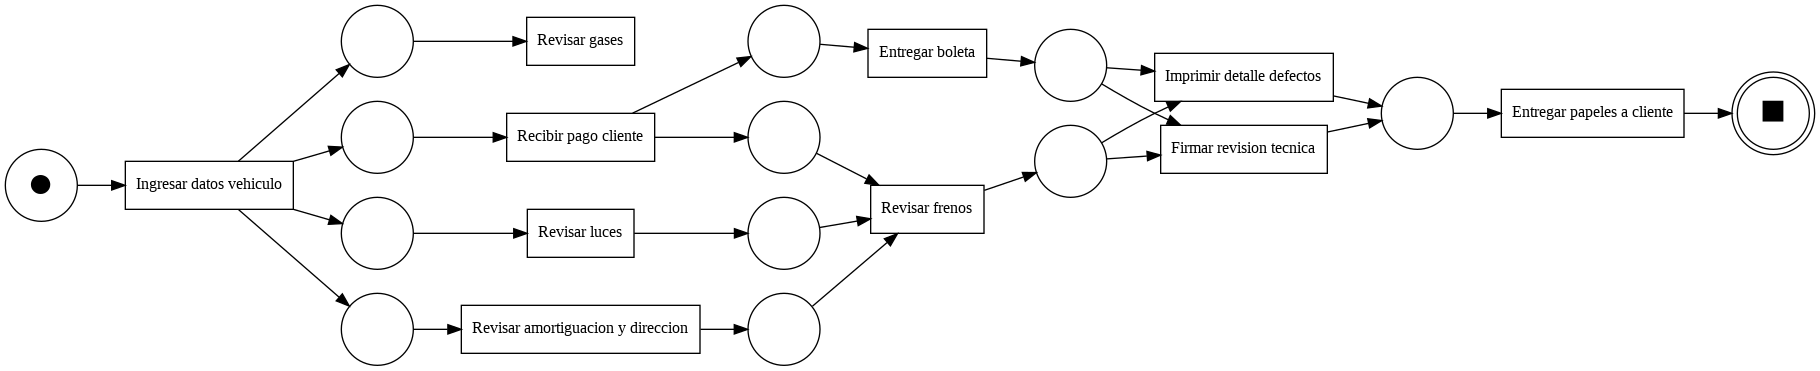

In [44]:
pm4py.vis.view_petri_net(net, initial_marking, final_marking, format='png')

## Descubrimiento de procesos con Inductive Miner

El **Inductive Miner** es un algoritmo más robusto que permite descubrir modelos de proceso estructurados y libres de bloqueos.

A diferencia del Alpha Miner, este enfoque:
- Maneja mejor el ruido.
- Garantiza modelos bien formados.
- Produce representaciones más claras del proceso.

El modelo obtenido se visualiza mediante un diagrama BPMN, facilitando la interpretación del flujo del proceso.


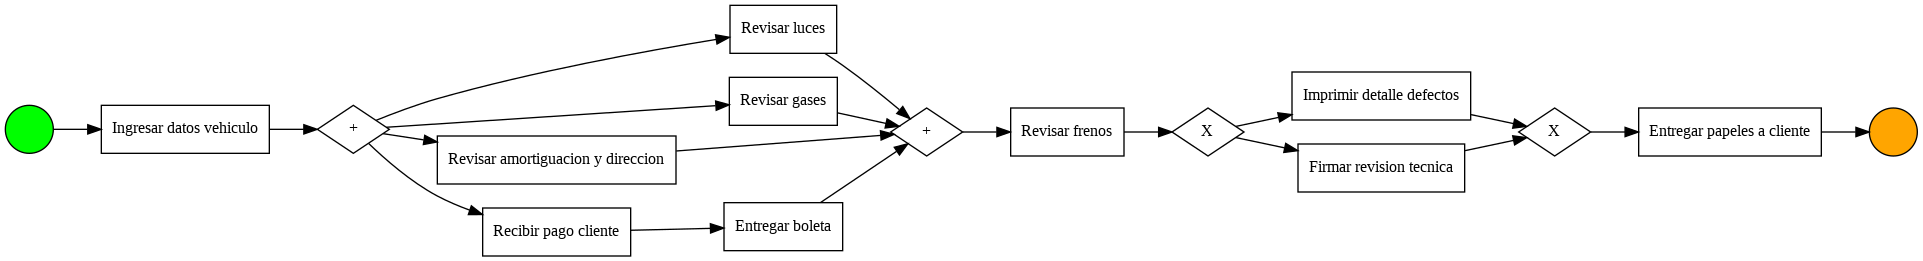

In [45]:
bpmn = pm4py.discover_bpmn_inductive(log_csv.copy(),
                                     noise_threshold = 0.05,
                                     disable_fallthroughs = False)

pm4py.view_bpmn(bpmn)

## Conformance Checking

En esta etapa se evalúa qué tan bien el modelo de proceso descubierto se ajusta a los datos reales.

El **Conformance Checking** permite identificar:
- Desviaciones entre el modelo y el log.
- Casos que no siguen el flujo esperado.
- Métricas de calidad como fitness y precisión.

Este análisis es clave para validar el modelo y detectar oportunidades de mejora en el proceso.


In [48]:
net_ideal, initial_marking_ideal, final_marking_ideal = pm4py.read_pnml("petri_net_proceso_ideal.pnml")

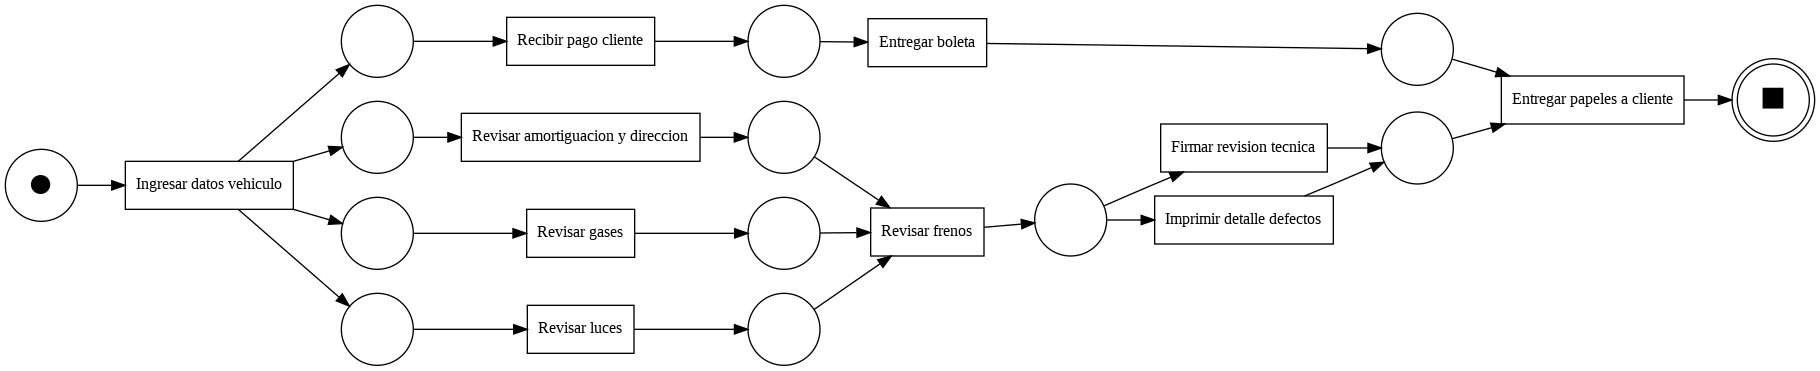

In [49]:
pm4py.vis.view_petri_net(net_ideal, initial_marking_ideal, final_marking_ideal, format='png')


In [50]:
fitness_results = pm4py.conformance.fitness_alignments(log_csv, net_ideal, initial_marking_ideal, final_marking_ideal)
fitness_results

aligning log, completed variants ::   0%|          | 0/70 [00:00<?, ?it/s]

{'percFitTraces': 100.0,
 'averageFitness': 1.0,
 'percentage_of_fitting_traces': 100.0,
 'average_trace_fitness': 1.0,
 'log_fitness': 1.0}

In [51]:
net_conf, initial_marking_conf, final_marking_conf = pm4py.read_pnml("petri_net_conformance.pnml")

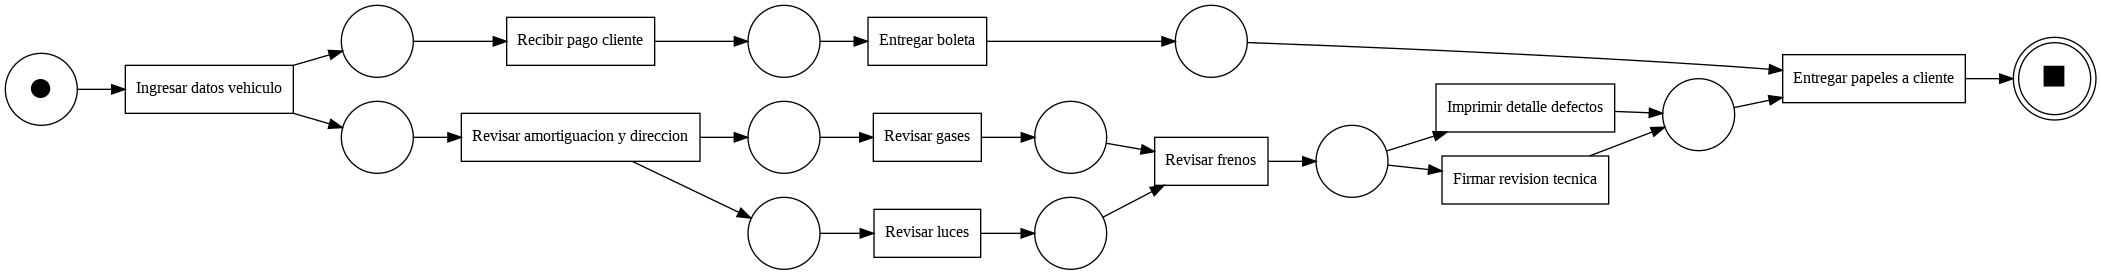

In [52]:
pm4py.vis.view_petri_net(net_conf, initial_marking_conf, final_marking_conf, format='png')


In [54]:
fitness_results_conf = pm4py.conformance.fitness_alignments(log_csv, net_conf, initial_marking_conf, final_marking_conf)
fitness_results_conf

aligning log, completed variants ::   0%|          | 0/70 [00:00<?, ?it/s]

{'percFitTraces': 25.9,
 'averageFitness': 0.9176666666666823,
 'percentage_of_fitting_traces': 25.9,
 'average_trace_fitness': 0.9176666666666823,
 'log_fitness': 0.9176666666666666}

In [55]:
precision = pm4py.conformance.precision_alignments(log_csv, net_conf, initial_marking_conf, final_marking_conf)

computing precision with alignments, completed variants ::   0%|          | 0/230 [00:00<?, ?it/s]

In [58]:
precision

0.9761669674168397

In [59]:
aligned_traces = pm4py.conformance_diagnostics_alignments(log_csv, net_conf, initial_marking_conf, final_marking_conf)

aligning log, completed variants ::   0%|          | 0/70 [00:00<?, ?it/s]

In [62]:
aligned_traces[5]

{'alignment': [('Ingresar datos vehiculo', 'Ingresar datos vehiculo'),
  ('Revisar gases', '>>'),
  ('Revisar amortiguacion y direccion', 'Revisar amortiguacion y direccion'),
  ('>>', 'Revisar gases'),
  ('Revisar luces', 'Revisar luces'),
  ('Recibir pago cliente', 'Recibir pago cliente'),
  ('Entregar boleta', 'Entregar boleta'),
  ('Revisar frenos', 'Revisar frenos'),
  ('Firmar revision tecnica', 'Firmar revision tecnica'),
  ('Entregar papeles a cliente', 'Entregar papeles a cliente')],
 'cost': 20000,
 'visited_states': 13,
 'queued_states': 45,
 'traversed_arcs': 47,
 'lp_solved': 13,
 'fitness': 0.8888888888888888,
 'bwc': 180000}

In [60]:
alignments = []
for e in aligned_traces:
  if e['alignment'] not in alignments:
    alignments.append(e['alignment'])

for al in alignments:
  print(al)

[('Ingresar datos vehiculo', 'Ingresar datos vehiculo'), ('Revisar amortiguacion y direccion', 'Revisar amortiguacion y direccion'), ('Revisar gases', 'Revisar gases'), ('Recibir pago cliente', 'Recibir pago cliente'), ('Revisar luces', 'Revisar luces'), ('Entregar boleta', 'Entregar boleta'), ('Revisar frenos', 'Revisar frenos'), ('Firmar revision tecnica', 'Firmar revision tecnica'), ('Entregar papeles a cliente', 'Entregar papeles a cliente')]
[('Ingresar datos vehiculo', 'Ingresar datos vehiculo'), ('Revisar gases', '>>'), ('Revisar amortiguacion y direccion', 'Revisar amortiguacion y direccion'), ('>>', 'Revisar gases'), ('Revisar luces', 'Revisar luces'), ('Recibir pago cliente', 'Recibir pago cliente'), ('Entregar boleta', 'Entregar boleta'), ('Revisar frenos', 'Revisar frenos'), ('Firmar revision tecnica', 'Firmar revision tecnica'), ('Entregar papeles a cliente', 'Entregar papeles a cliente')]
[('Ingresar datos vehiculo', 'Ingresar datos vehiculo'), ('Recibir pago cliente', 'R

## Conclusiones

A partir de la aplicación de técnicas de minería de procesos, fue posible descubrir y analizar el comportamiento real del proceso estudiado.

Los algoritmos utilizados permitieron:
- Comprender la estructura del proceso.
- Comparar diferentes enfoques de descubrimiento.
- Evaluar el grado de cumplimiento entre los datos y los modelos obtenidos.

Este tipo de análisis resulta especialmente útil para la optimización de procesos, auditoría y mejora continua basada en datos.
